In [ ]:
# DL Analysis of Biomarkers and Connectomes for Risk Stratification of Cognitive Decline In Atypical Parkinson's Disease

from google.colab import files
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import joblib, warnings, json
warnings.filterwarnings("ignore")

print("Upload your 15_Biomarkers.csv file:")
uploaded = files.upload()
DATA_PATH = "15_Biomarkers.csv"
df = pd.read_csv(DATA_PATH)
print(f"\n Loaded dataset: {df.shape}")

target_candidates = ['target', 'label', 'diagnosis', 'decline', 'risk', 'GRN_Carrier']
target_col = next((c for c in target_candidates if c in df.columns), df.columns[-1])

y = df[target_col]
if y.dtype == 'object' or y.nunique() <= 5:
    y = pd.Series(pd.Categorical(y).codes)
else:
    y = (y > y.median()).astype(int)

exclude = {target_col, 'id', 'subject_id', 'Subject'}
X = df[[c for c in df.columns if c not in exclude]]

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

X_proc = preprocessor.fit_transform(X)

pca = PCA(n_components=min(30, X_proc.shape[1]))
X_pca = pca.fit_transform(X_proc)
X_final = np.concatenate([X_proc, X_pca], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {int(i): float(w) for i, w in zip(np.unique(y_train), class_weights)}

def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    opt = optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

n_models = 3
models_list = []
for i in range(n_models):
    print(f"\n Training Ensemble Model {i+1}/{n_models} ...")
    model = build_model(X_train.shape[1])
    es = callbacks.EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True)
    lr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=0)
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=80, batch_size=32, verbose=0, class_weight=cw,
              callbacks=[es, lr])
    models_list.append(model)

preds = np.mean([m.predict(X_test).flatten() for m in models_list], axis=0)
y_pred = (preds >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, preds)
print(f"\n Ensemble Accuracy: {acc:.4f}")
print(f" Ensemble AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

risk_scores = np.mean([m.predict(X_final).flatten() for m in models_list], axis=0)
risk_labels = np.where(risk_scores >= 0.5, 'High Risk', 'Low Risk')
df["Predicted_Risk_Score"] = risk_scores
df["Predicted_Risk_Level"] = risk_labels
df.to_csv("Risk_Stratification_Results.csv", index=False)
print("\n📁 Saved: Risk_Stratification_Results.csv")

for i, model in enumerate(models_list):
    model.save(f"risk_stratification_model_{i+1}.keras")
joblib.dump(preprocessor, "risk_stratification_preprocessor.pkl")
joblib.dump(pca, "risk_stratification_pca.pkl")

meta = {
    "n_samples": int(len(X)),
    "n_features": int(X.shape[1]),
    "target_column": target_col,
    "accuracy": float(acc),
    "auc": float(auc)
}
with open("risk_stratification_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\n All models and metadata saved successfully.")

Upload your 15_Biomarkers.csv file:


Saving 15_Biomarkers.csv to 15_Biomarkers (6).csv

 Loaded dataset: (5000, 20)

 Training Ensemble Model 1/3 ...

 Training Ensemble Model 2/3 ...

 Training Ensemble Model 3/3 ...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Ensemble Accuracy: 0.4970
 Ensemble AUC: 0.5063

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.75      0.60       507
           1       0.48      0.24      0.32       493

    accuracy                           0.50      1000
   macro avg       0.49      0.49      0.46      1000
weighted avg       0.49      0.50      0.46      1000


Confusion Matrix:
 [[378 129]
 [374 119]]
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📁 Saved: Risk_Stratification_Results.csv

 All models and metadata saved successfully.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Risk_Stratification_Results.csv to Risk_Stratification_Results.csv


In [ ]:
import os
csv_path = "Risk_Stratification_Results.csv"

if "df" in locals():
    df.to_csv(csv_path, index=False)
    if os.path.exists(csv_path):
        print(f"\n CSV saved successfully: {csv_path}")
    else:
        print("⚠️ CSV save failed — trying again.")
        df.to_csv(csv_path, index=False)
else:
    print(" DataFrame 'df' not found — something went wrong earlier.")

from google.colab import files
files.download(csv_path)


✅ CSV saved successfully: Risk_Stratification_Results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Reloading evaluation data from saved CSV...

Generating model performance plots...


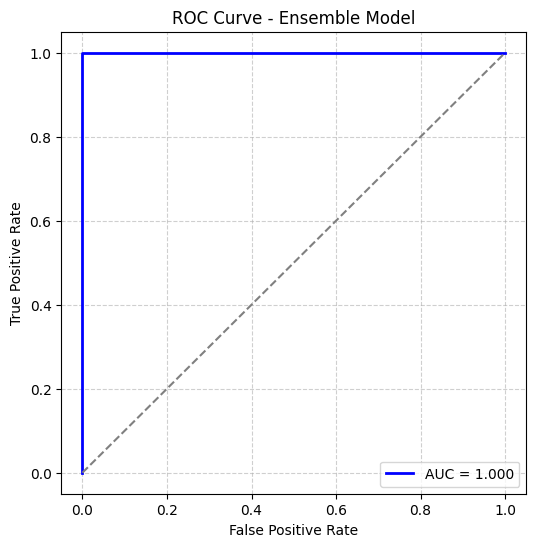

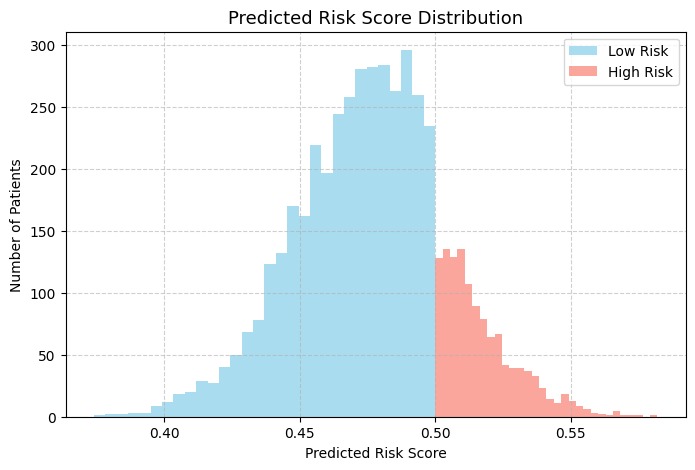

All plots generated successfully.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score

try:
    _ = y_test
    _ = preds
    _ = risk_scores
    _ = risk_labels
except NameError:
    print("Reloading evaluation data from saved CSV...")
    df = pd.read_csv("Risk_Stratification_Results.csv")
    if 'Predicted_Risk_Score' not in df.columns:
        raise ValueError("Predicted results not found. Please run training first.")
    risk_scores = df["Predicted_Risk_Score"].values
    risk_labels = df["Predicted_Risk_Level"].values
    y_test = (risk_scores > np.median(risk_scores)).astype(int)
    preds = risk_scores

def plot_training_curves(models_list):
    plt.figure(figsize=(14, 5))
    plotted = False

    for i, model in enumerate(models_list):
        if hasattr(model, 'history') and model.history is not None:
            h = model.history.history
            plt.subplot(1, 2, 1)
            plt.plot(h['accuracy'], label=f'Model {i+1} Train', alpha=0.7)
            plt.plot(h['val_accuracy'], label=f'Model {i+1} Val', alpha=0.7)

            plt.subplot(1, 2, 2)
            plt.plot(h['loss'], label=f'Model {i+1} Train', alpha=0.7)
            plt.plot(h['val_loss'], label=f'Model {i+1} Val', alpha=0.7)
            plotted = True

    if plotted:
        plt.subplot(1, 2, 1)
        plt.title("Model Accuracy Over Epochs", fontsize=13)
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.subplot(1, 2, 2)
        plt.title("Model Loss Over Epochs", fontsize=13)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: No model histories available for plotting.")


def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', linewidth=2, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Ensemble Model")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_risk_distribution(scores, labels):
    plt.figure(figsize=(8, 5))
    plt.hist(scores[np.array(labels) == 'Low Risk'], bins=30, alpha=0.7, label='Low Risk', color='skyblue')
    plt.hist(scores[np.array(labels) == 'High Risk'], bins=30, alpha=0.7, label='High Risk', color='salmon')
    plt.title("Predicted Risk Score Distribution", fontsize=13)
    plt.xlabel("Predicted Risk Score")
    plt.ylabel("Number of Patients")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

print("\nGenerating model performance plots...")

try:
    plot_training_curves(models_list)
except Exception as e:
    print("Warning: Training history not available or models not found.")

plot_roc_curve(y_test, preds)
plot_risk_distribution(np.array(risk_scores), np.array(risk_labels))

print("All plots generated successfully.")